# Frozen Lake Environment

## 🧊 What Is Frozen Lake?
- It is a grid-world, where agent is supposed to move from the start cell/state namely "S", to the goal state "G" while walking on frozen cell "F" and avoiding the holes "H".

- A typical froken environment looks like this

```
S F F F
F H F H
F F F H
H F F G
```
- S : starting point
- G : Goal (successful termination)
- F : frozen cell (safe to move)
- H : hole (falling ends the episode)

## 🎮 How the Environment Works
- *State space*: Each grid cell is a state
- *Action space*: Discrete actions
- 0: `Left`
- 1: `Down`
- 2: `Right`
- 3: `Up`

Reward structure:
- +10 for reaching the goal
- -1 moving in the frozen tile
- -10 for falling into a hole

Episode ends if the agent reaches the goal or falls into a hole

## ❄️ Slippery vs Non-Slippery

Frozen Lake is interesting because it can be stochastic:

- Slippery mode (default):
   - The agent may slip and move in an unintended direction
   - Actions are not deterministic

- Non-slippery mode:
   - Actions always move exactly as intended

This makes it a great environment for testing planning under uncertainty.

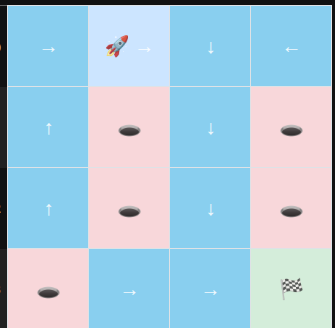

## Create frozen lake environment

Now let's create a frozen lake environment class; following is the overview of what we are trying to build:
1. Create a helper function to create a grid based on provided parameters.
2. User should be able to pass the grid (2D list that contains the information about the starting point, frozen cell, holes and the goal)
3. User should determine whether the action is going to be deterministic or stochastic based on slipper mode.
4. State will be represented by row and column index. Later in our learning journey we will will a single index-based state representation. 
5. There should be a method that takes current state and action, and based on that, it should return a list of dictionary that contain the following fields `prob, next_state, reward, done` where
    - `prob`: probability of moving to the `new_state`
    - `new_state`: the new state row and column index
    - `reward`: reward for moving into the `new_state`
    - `done`: represent whether the agent has reached into a terminal state (i.e., reached to the goal state or felt down the hole)

## 1. Helper function to generate a frozen lake grid 

In [51]:
import random
import numpy as np

In [52]:
def generate_grid_randomly(n_rows, n_cols, n_holes=4):
    """
    Generate a random 2D Frozen Lake grid.

    The grid consists of:
    - 'F' : Frozen (safe) cells
    - 'H' : Holes (terminal failure states)
    - 'S' : Start state
    - 'G' : Goal state

    Args:
        n_rows (int): Number of rows in the grid.
        n_cols (int): Number of columns in the grid.
        n_holes (int, optional): Number of hole cells to place.
            Defaults to 4.

    Returns:
        list[list[str]]: A 2D list representing the Frozen Lake grid.
    """
    
    grid = [["F" for _ in range(n_cols)] for _ in range(n_rows)]    
    states = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    
    random.shuffle(states)

    for i in range(0, n_holes):
        hole = states[i%(n_rows*n_cols)]
        r, c = hole
        grid[r][c] = "H"

    # start state
    r, c = states[-1]
    grid[r][c] = "S"
    
    # goal state
    r, c = states[-2]
    grid[r][c] = "G"

    return grid

In [53]:
grid = generate_grid_randomly(4, 4, n_holes=2)
grid

[['F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F'],
 ['F', 'S', 'F', 'F'],
 ['F', 'F', 'H', 'G']]

## 2. Frozen lake Enviornment Class

Now let's create a frozen lake environment class. In this section, we are just going to figure out the constant and init parameters of our class. 

In [96]:
class FrozenLakeEnvironment:
    def __init__(self, grid, reward_points, slippery=True):
        """
        grid (list): 2D list defining the frozen lake environment
        reward_points: reward for G, H, F states  
        slippery (bool): determine whether the actions are deterministic or not 
        """
        
        self.grid = grid

        self.slippery = slippery
        self.action_to_idx_mapper = {
                               "left":  0,
                               "down": 1,
                               "right": 2,
                               "up": 3
                            }
        self.reward_points = reward_points
        
        self.terminal_states = ["G", "H"] # goals and hols are the terminal states
        
        self.action_idx_to_step_mapper = {
             0: (0, -1), # left means staying in the same row (row unchanged), moving one column left from the current cell i.e -1
             1: (1, 0), # down means moving to the next row (+1 row) but staying in the same column
             2: (0, 1), # right means staying in the same row (row unchanged), moving to the subsequent right column i.e +1
             3: (-1, 0) # up means staying in the same column but moving one row up i.e -1 
        }
    def n_actions(self):
        return len(self.action_to_idx_mapper)
    
    def n_rows(self):
        return len(grid)
    
    def n_cols(self):
        return len(grid[0])
    
    def n_states(self):
        return self.n_rows() * self.n_cols()

## 2.1 Essential Methods
Now let's define few essential methods that define the dynamics of the environment

### 2.1.1 Move method
- Determine the next state based on the current state and the action. Note that here we are not going to define the slippery logic.
- This method is just going to be determine the next allowed state for the given aciton.

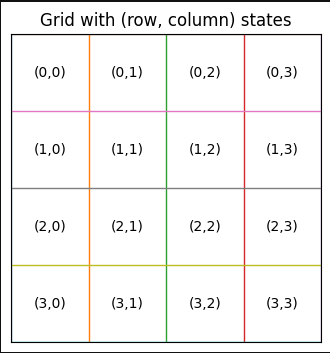

In [97]:
def move(self, current_state, action_idx):
    r, c = current_state
    # Note that we are representing state as a combination of row idx and column idx like a coordinate system 
    step_r, step_c = self.action_idx_to_step_mapper[action_idx]
    new_r = min(max(0, r+step_r), self.n_rows() -1) #make sure step is a valid one
    new_c = min(max(0, c+step_c), self.n_cols() -1)
    return new_r, new_c

In [98]:
reward_points = {
    "G": 1,
    "F": 0,
    "H": 0
}

env = FrozenLakeEnvironment(grid, reward_points)

In [99]:
print("move one step right from state (1, 1) --> ", move(env, (1, 1), env.action_to_idx_mapper["right"]))
print("move one step left from state (1, 1) --> ", move(env, (1, 1), env.action_to_idx_mapper["left"]))
print("move one step up from state (1, 1) --> ", move(env, (1, 1), env.action_to_idx_mapper["up"]))
print("move one step down from state (1, 1) --> ", move(env, (1, 1), env.action_to_idx_mapper["down"]))

print("==invalid move==")
print("move one step right from state (1, 1) --> ", move(env, (0, 0), env.action_to_idx_mapper["up"]))

move one step right from state (1, 1) -->  (1, 2)
move one step left from state (1, 1) -->  (1, 0)
move one step up from state (1, 1) -->  (0, 1)
move one step down from state (1, 1) -->  (2, 1)
==invalid move==
move one step right from state (1, 1) -->  (0, 0)


### 2.1.2 Is Terminal State
- Function to check whether the given state is a terminal state or not

In [100]:
def is_terminal_state(self, state):
    r, c = state
    return self.grid[r][c] in self.terminal_states

In [112]:
grid = [['F', 'F', 'F', 'H'],
        ['F', 'F', 'F', 'F'],
        ['F', 'S', 'G', 'F'],
        ['F', 'F', 'H', 'F']]
grid

[['F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F'],
 ['F', 'S', 'G', 'F'],
 ['F', 'F', 'H', 'F']]

In [113]:
print("Is (0, 0) as terminal state ? ", is_terminal_state(env, (0, 0))) # state F
print("Is (0, 2) as terminal state ? ", is_terminal_state(env, (0, 3))) # state H
print("Is (2, 1) as terminal state ? ", is_terminal_state(env, (2, 1))) # state S
print("Is (3, 2) as terminal state ? ", is_terminal_state(env, (3, 2))) # state G

Is (0, 0) as terminal state ?  False
Is (0, 2) as terminal state ?  True
Is (2, 1) as terminal state ?  False
Is (3, 2) as terminal state ?  True


### 2.1.3 transition probability
Now let's define the dynamics of the model (note that we are modeling the transition probability and will return it)

In [130]:
def get_transition_prob(self, state, action):
    """
    Compute the transition dynamics for a given state-action pair.

    Returns a list of possible transitions, each defined by the
    transition probability, next state, reward, and terminal flag.
    The environment supports both deterministic and stochastic
    (slippery) dynamics.

    If the current state is terminal, the agent remains in the same
    state with probability 1 and receives zero reward.

    In slippery mode, the intended action succeeds with probability
    0.8, while the agent slips to the left or right action with
    probability 0.1 each.

    Args:
        state (tuple[int, int]): Current (row, column) state.
        action (int): Action index chosen by the agent.

    Returns:
        list[dict]: A list of transition dictionaries with keys:
            - "prob" (float): Transition probability.
            - "new_state" (tuple[int, int]): Resulting state.
            - "reward" (float): Reward received after the transition.
            - "done" (bool): Whether the next state is terminal.
    """
    
    if self.is_terminal_state(state):
        # if it is terminal state do not move
        return [{"prob": 1.0,
                 "new_state": state,
                 "reward": 0,
                 "done": True}]

    # --- deterministic action -------
    actions_prob = {
        action: 1.0
    }
    
    # --- stochastic action ----------
    if self.slippery: 
        # action-prob pair
        actions_prob = {
            action: 0.7,
            (action + 1)%self.n_actions(): 0.1,
            (action + 2)%self.n_actions(): 0.1,
            (action + 3)%self.n_actions(): 0.1
        }
    # --------------------------------
    transitions = []
    for action, prob in actions_prob.items():
        new_state = self.move(state, action)
        r, c = new_state
        cell = self.grid[r][c]
                   
        reward = self.reward_points[cell]    
        
        game_over = cell in self.terminal_states
        transitions.append({"prob": prob,
                            "new_state": new_state,
                            "reward": reward,
                            "done": game_over})
    return transitions

In [131]:
reward_points = {
    "G": 1,
    "F": 0,
    "H": 0
}

env = FrozenLakeEnvironment(grid, reward_points)

In [132]:
get_transition_prob(env, (3, 2), env.action_to_idx_mapper["left"])

[{'prob': 1.0, 'new_state': (3, 2), 'reward': 0, 'done': True}]

In [133]:
env.get_transition_prob((1, 2), env.action_to_idx_mapper["left"])

[{'prob': 0.7, 'new_state': (1, 1), 'reward': 0, 'done': False},
 {'prob': 0.1, 'new_state': (2, 2), 'reward': 1, 'done': True},
 {'prob': 0.1, 'new_state': (1, 3), 'reward': 0, 'done': False},
 {'prob': 0.1, 'new_state': (0, 2), 'reward': 0, 'done': False}]

## 2.2 Complete class definition

In [124]:
class FrozenLakeEnvironment:
    def __init__(self, grid, reward_points, slippery=True):     
        self.grid = grid

        self.slippery = slippery
        self.action_to_idx_mapper = {
                               "left":  0,
                               "down": 1,
                               "right": 2,
                               "up": 3
                            }
        self.reward_points = reward_points
        
        self.terminal_states = ["G", "H"] 
        
        self.action_idx_to_step_mapper = {
             0: (0, -1), 
             1: (1, 0),
             2: (0, 1),
             3: (-1, 0)
        }

    def n_actions(self):
        return len(self.action_to_idx_mapper)
    def n_rows(self):
        return len(grid)
    def n_cols(self):
        return len(grid[0])
    def n_states(self):
        return self.n_rows() * self.n_cols()
        
    def move(self, current_state, action_idx):
        r, c = current_state
        # Note that we are representing state as a combination of row idx and column idx like a coordinate system 
        step_r, step_c = self.action_idx_to_step_mapper[action_idx]
        new_r = min(max(0, r+step_r), self.n_rows() -1) #make sure step is a valid one
        new_c = min(max(0, c+step_c), self.n_cols() -1)
        return new_r, new_c

    def is_terminal_state(self, state):
        r, c = state
        return self.grid[r][c] in self.terminal_states

        
    def get_transition_prob(self, state, action):
        if self.is_terminal_state(state):
            # if it is terminal state do not move
            return [{"prob": 1.0,
                     "new_state": state,
                     "reward": 0,
                     "done": True}]

        # --- deterministic action -------
        actions_prob = {
            action: 1.0
        }
        
        # --- stochastic action ----------
        if self.slippery: 
            # action-prob pair
            actions_prob = {
                action: 0.7,
                (action + 1)%self.n_actions(): 0.1,
                (action + 2)%self.n_actions(): 0.1,
                (action + 3)%self.n_actions(): 0.1
            }
        # --------------------------------
        transitions = []
        for action, prob in actions_prob.items():
            new_state = self.move(state, action)
            r, c = new_state
            cell = self.grid[r][c]
                       
            reward = self.reward_points[cell]    
            
            game_over = cell in self.terminal_states
            transitions.append({"prob": prob,
                                "new_state": new_state,
                                "reward": reward,
                                "done": game_over})
        return transitions

In [139]:
reward_points = {
    "G": 1,
    "F": 0,
    "H": 0
}

env = FrozenLakeEnvironment(grid, reward_points)

In [140]:
print("Number of rows: ", env.n_rows())
print("Number of columns: ", env.n_cols())
print("Number of states: ", env.n_states())
print("Number of actions: ", env.n_actions())

Number of rows:  4
Number of columns:  4
Number of states:  16
Number of actions:  4


In [141]:
grid

[['F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F'],
 ['F', 'S', 'G', 'F'],
 ['F', 'F', 'H', 'F']]

In [142]:
# scenerio 1: when current state is Goal state (G) or terminal state
env.get_transition_prob((3, 2), env.action_to_idx_mapper["left"])

[{'prob': 1.0, 'new_state': (3, 2), 'reward': 0, 'done': True}]

One will be stuck in the terminal state, thus transition probability for staying at the same state is 1.0. 

In [145]:
# scenario 2: when current state is Frozen (F) state and the environment is stochastic (slippery=True)
env.get_transition_prob((1, 2), env.action_to_idx_mapper["left"])

[{'prob': 0.7, 'new_state': (1, 1), 'reward': 0, 'done': False},
 {'prob': 0.1, 'new_state': (2, 2), 'reward': 1, 'done': True},
 {'prob': 0.1, 'new_state': (1, 3), 'reward': 0, 'done': False},
 {'prob': 0.1, 'new_state': (0, 2), 'reward': 0, 'done': False}]

In [146]:
# scenario 3: when current state is Frozen (F) state and the environment is deterministic (slippery=False)
env = FrozenLakeEnvironment(grid, reward_points, slippery=False)
env.get_transition_prob((1, 2), env.action_to_idx_mapper["left"])

[{'prob': 1.0, 'new_state': (1, 1), 'reward': 0, 'done': False}]

In the deterministic environment, if you want to move to left/right/up/down you will move to that direction with probability 1.0

# In conclusion
- We have successfully created a frozen lake class from scratch. In the upcoming implementations, we will be using this same class or maybe with a few adjustments on it.
- `get_transition_prob` is returning the probability of moving to any possible directions, thus it is suitable for model-based reinforcement learning where we already know the dynamics of the environment through the transition probability.
- In later implementations, particularly in model-free reinforcement learning, we will deprecate the `get_transition_prob` method and create a new one that won't return the transition probability. 